# 19. Melt, Density, and Bulk Dissipation

A partial-melt model weakens a material's shear modulus and viscosity, and that is all it does by default. Melt has other effects, each behind its own switch on the partial-melt model, all off by default:

| Switch | Effect |
|---|---|
| `density_melt_mixing` | The melt enters the density the structure solve integrates. |
| `bulk_melt_weakening` | The bulk modulus is the two-phase (Hashin-Shtrikman) bound, with the melt's bulk modulus at the local pressure. |
| `bulk_viscosity_melt_weakening` | Melt sets a compaction bulk viscosity, $c\,\eta/\phi^n$, in series with the pre-melt one. |

The melt phase has its own pressure law, a Murnaghan law set by `liquid_density_kg_m3`, `liquid_bulk_modulus_pa`, and `liquid_bulk_modulus_derivative`. A bulk viscosity only dissipates through a bulk rheology that is not elastic, and the right one for it is the Zener (standard linear solid) rheology, which relaxes to a set fraction of the bulk modulus rather than to zero.

This notebook:

1. compares the Zener and Maxwell rheologies;
2. follows one material point through its melting range with each switch;
3. applies the switches to Io with a partially molten asthenosphere;
4. shows why a Maxwell bulk rheology misleads, and when a bulk response matters at all;
5. shows what mixing the melt into the density does to the structure.

In [1]:
%matplotlib inline
import copy
import math

import numpy as np
import matplotlib.pyplot as plt

from TidalPy.Material.eos import make_material_eos
from TidalPy.Rheology import maxwell, zener
from TidalPy.Structures import build_world
from TidalPy.Structures.configs.world_builder import construct_world

DAY = 86400.0
IO_FREQUENCY = 2.0 * math.pi / (1.769138 * DAY)  # Io's orbital mean motion [rad/s]
IO_ECCENTRICITY, IO_SEMI_MAJOR_AXIS, JUPITER_MASS = 0.0041, 4.217e8, 1.898e27

## Zener and Maxwell

The Zener rheology is a spring of the relaxed modulus $rM$ in parallel with a Maxwell arm that holds the rest, $(1 - r)M$:

$$M^{*} = rM + (1 - r)M\,\frac{i\omega\tau}{1 + i\omega\tau}, \qquad \tau = \frac{\eta}{(1 - r)M}.$$

At high frequency it is $M$; at low frequency it relaxes to $rM$, where a Maxwell body relaxes to zero. $r = 0$ is Maxwell. Below, each curve is plotted against $\omega\tau$, so the loss peaks line up at 1.

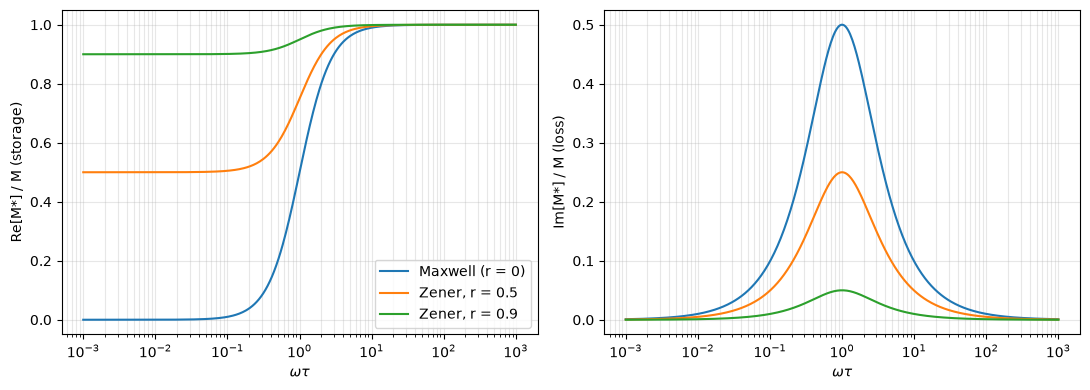

In [2]:
modulus, viscosity = 1.0, 1.0
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
omega_tau = np.logspace(-3, 3, 400)
for r in (0.0, 0.5, 0.9):
    # tau = eta / ((1 - r) M), so omega = omega_tau (1 - r) M / eta; r = 0 is Maxwell.
    frequency = omega_tau * (1.0 - r) * modulus / viscosity
    response = zener(modulus, viscosity, frequency, relaxed_modulus_frac=r)
    label = "Maxwell (r = 0)" if r == 0.0 else f"Zener, r = {r}"
    axes[0].semilogx(omega_tau, response.real, label=label)
    axes[1].semilogx(omega_tau, response.imag, label=label)
assert np.allclose(zener(1.0, 1.0, 0.7, relaxed_modulus_frac=0.0), maxwell(1.0, 1.0, 0.7))
axes[0].set_ylabel("Re[M*] / M (storage)")
axes[1].set_ylabel("Im[M*] / M (loss)")
for ax in axes:
    ax.set_xlabel(r"$\omega\tau$")
    ax.grid(True, which="both", alpha=0.3)
axes[0].legend()
plt.tight_layout()

## One Material Point Through Its Melting Range

Io's asthenosphere material (a Birch-Murnaghan rock with a Henning melt model, solidus 1600 K and liquidus 2000 K) evaluated at 0.3 GPa, mid-asthenosphere, from 1500 to 2000 K, with each switch off and on. Io's layers use an athermal density law, so the sweep does too (`thermal_density=False`). `calc_material_state` is the same function the equation-of-state solve evaluates.

melt fraction runs from 0.00 to 1.00


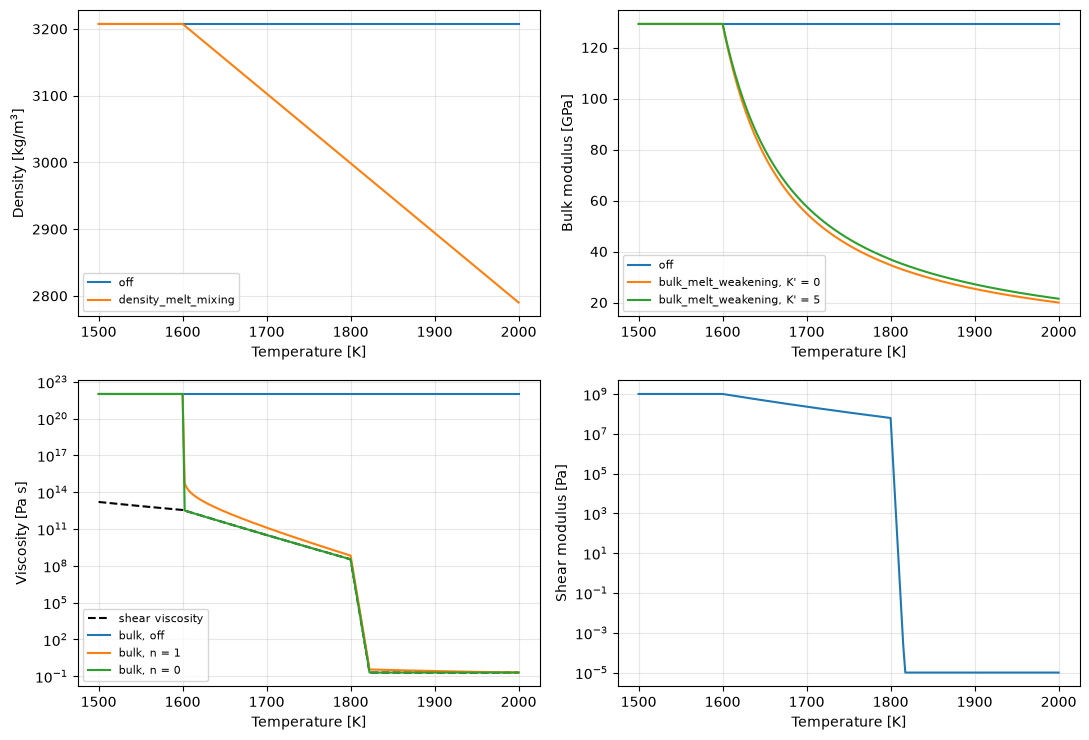

In [3]:
io_config = build_world("io").get_config_dict()
asthenosphere_material = io_config["layers"]["asthenosphere"]["material"]


def material(**melt_switches):
    config = copy.deepcopy(asthenosphere_material)
    config["partial_melt"].update(melt_switches)
    return make_material_eos(config.pop("model"), config)


pressure = 3.0e8
temperatures = np.linspace(1500.0, 2000.0, 201)


def sweep(model, key):
    return np.array([model.calc_material_state(pressure, T, thermal_density=False)[key] for T in temperatures])


off = material()
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
axes[0, 0].plot(temperatures, sweep(off, "density"), label="off")
axes[0, 0].plot(temperatures, sweep(material(density_melt_mixing=True), "density"), label="density_melt_mixing")
axes[0, 0].set_ylabel("Density [kg/m$^3$]")
axes[0, 1].plot(temperatures, sweep(off, "bulk_modulus") / 1e9, label="off")
axes[0, 1].plot(temperatures, sweep(material(bulk_melt_weakening=True, liquid_bulk_modulus_derivative=0.0),
                                    "bulk_modulus") / 1e9, label="bulk_melt_weakening, K' = 0")
axes[0, 1].plot(temperatures, sweep(material(bulk_melt_weakening=True), "bulk_modulus") / 1e9,
                label="bulk_melt_weakening, K' = 5")
axes[0, 1].set_ylabel("Bulk modulus [GPa]")
axes[1, 0].semilogy(temperatures, sweep(off, "shear_viscosity"), "k--", label="shear viscosity")
axes[1, 0].semilogy(temperatures, sweep(off, "bulk_viscosity"), label="bulk, off")
for exponent in (1.0, 0.0):
    model = material(bulk_viscosity_melt_weakening=True, melt_bulk_viscosity_exponent=exponent)
    axes[1, 0].semilogy(temperatures, sweep(model, "bulk_viscosity"), label=f"bulk, n = {exponent:g}")
axes[1, 0].set_ylabel("Viscosity [Pa s]")
axes[1, 1].semilogy(temperatures, sweep(off, "shear_modulus"))
axes[1, 1].set_ylabel("Shear modulus [Pa]")
melt_fraction = sweep(off, "melt_fraction")
for ax in axes.flat:
    ax.set_xlabel("Temperature [K]")
    ax.grid(True, alpha=0.3)
    if ax.get_legend_handles_labels()[0]:
        ax.legend(fontsize=8)
plt.tight_layout()
print(f"melt fraction runs from {melt_fraction.min():.2f} to {melt_fraction.max():.2f}")

Each switch acts from the solidus on:

- **Density.** Silicate melt is lighter than the rock at this pressure, so the mixture thins as it melts. The melt law is isothermal and more compressible than the rock, so deep enough the melt can become the denser phase (the density crossover of silicate melts); the mixture handles either case.
- **Bulk modulus.** It falls only modestly while the solid framework holds. Once the Henning model collapses the framework's shear modulus past the critical melt fraction, it drops to the Reuss average of a suspension. A pressure-dependent melt ($K' = 5$) is stiffer than a constant one at any positive pressure, so it weakens the rock less.
- **Bulk viscosity.** Without melt it is the pre-melt value, $10^{22}$ Pa s here. Melt brings it down to the compaction value. McKenzie's $n = 1$ keeps it a factor $1/\phi$ above the shear viscosity; $n = 0$ sets it equal to the shear viscosity.

## Io With a Partially Molten Asthenosphere

The bundled Io keeps its asthenosphere at the solidus, so no melt acts. Raised to 1650 K it is 12.5% molten. The table below solves $k_2$ at the orbital period and the tidal heating, adding one switch at a time. The mass is not refitted: the structure solve simply integrates whatever density the switches give.

In [4]:
def io_world(temperature=1650.0, bulk_rheology=None, **melt_switches):
    config = copy.deepcopy(io_config)
    layer = config["layers"]["asthenosphere"]
    layer["temperature_k"] = temperature
    layer["material"]["partial_melt"].update(melt_switches)
    if bulk_rheology is not None:
        layer["bulk_rheology"] = bulk_rheology
    world = construct_world(config)
    result = world.solve_eos()
    assert result["success"], result["message"]
    return world


def love_k2(world, frequency=IO_FREQUENCY):
    result = world.solve_love_numbers(frequency=frequency, degree_l=2)
    assert result["success"], result["message"]
    return complex(world.love_number_k)


def heating(world):
    world.calc_tides(IO_FREQUENCY, IO_FREQUENCY, IO_ECCENTRICITY, 0.0, IO_SEMI_MAJOR_AXIS, JUPITER_MASS)
    return world.get_tidal_heating()


ZENER = {"model": "zener", "relaxed_modulus_frac": 0.5}
BULK = dict(bulk_melt_weakening=True, bulk_viscosity_melt_weakening=True)
cases = [
    ("at the solidus (bundled Io)", dict(temperature=1600.0)),
    ("shear melt weakening only", dict()),
    ("+ bulk_melt_weakening", dict(bulk_melt_weakening=True)),
    ("+ melt bulk viscosity, Zener r = 0.5", dict(bulk_rheology=ZENER, **BULK)),
    ("+ melt bulk viscosity, Maxwell", dict(bulk_rheology={"model": "maxwell"}, **BULK)),
    ("+ density_melt_mixing (with Zener)", dict(bulk_rheology=ZENER, density_melt_mixing=True, **BULK)),
]
print(f"{'case':38s} {'Re k2':>8s} {'-Im k2':>8s} {'Q':>6s} {'heating [W]':>12s} {'mass [kg]':>11s}")
for label, kwargs in cases:
    world = io_world(**kwargs)
    k2 = love_k2(world)
    print(f"{label:38s} {k2.real:8.4f} {-k2.imag:8.4f} {abs(k2) / -k2.imag:6.2f} {heating(world):12.3e} "
          f"{world.planet_mass_eos:11.4e}")

case                                      Re k2   -Im k2      Q  heating [W]   mass [kg]
at the solidus (bundled Io)              0.0357   0.0150   2.58    9.329e+13  8.9298e+22
shear melt weakening only                0.0612   0.1405   1.09    8.740e+14  8.9298e+22
+ bulk_melt_weakening                    0.0612   0.1405   1.09    8.739e+14  8.9298e+22
+ melt bulk viscosity, Zener r = 0.5     0.0611   0.1405   1.09    8.738e+14  8.9298e+22
+ melt bulk viscosity, Maxwell           0.0826   0.1025   1.28    6.377e+14  8.9298e+22
+ density_melt_mixing (with Zener)       0.0599   0.1359   1.09    8.452e+14  8.9085e+22


- **Shear weakening.** Melting the asthenosphere by 12.5% multiplies the heating by about nine; that is the shear weakening.
- **Bulk modulus.** Weakening it with the melt changes $k_2$ in the fourth digit.
- **Zener bulk viscosity.** With a Zener bulk rheology the melt's bulk viscosity barely registers either.
- **Maxwell bulk viscosity.** With a Maxwell bulk rheology the heating falls by a quarter and $k_2$ moves by a third. That comes from the bulk modulus relaxing to nearly zero, not from any real bulk dissipation.
- **Density mixing.** Mixing the lighter melt into the density thins the asthenosphere by about 1.6%. With the radii fixed, Io then holds 0.24% less mass, which a real model would refit.

## Maxwell Against Zener Across Forcing Periods

A Maxwell bulk rheology relaxes the bulk modulus toward zero once the forcing is slower than $\zeta / K$. For the melt's compaction viscosity here that is about half a minute, so at tidal periods the Maxwell layer has almost no bulk stiffness left, and from a few days on its $k_2$ departs far from the elastic answer. A Zener bulk rheology stays within a factor $r$ of the unrelaxed modulus and tracks the elastic answer. The grey line is Io's orbital period.

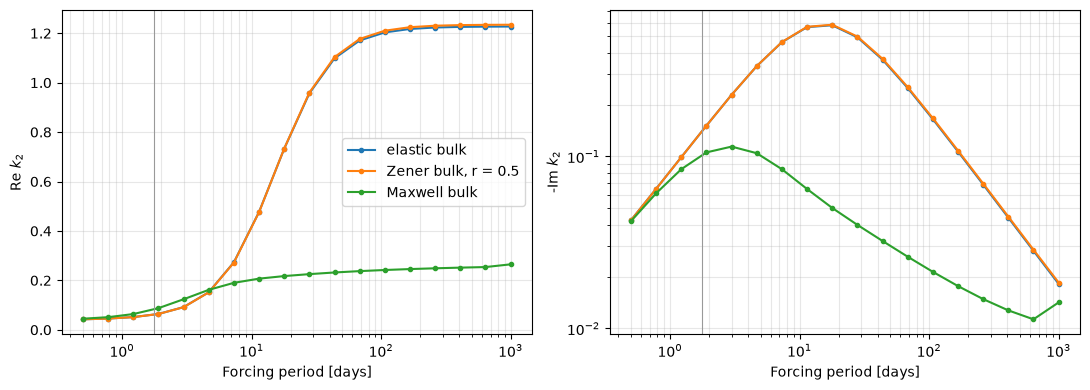

In [5]:
periods = np.logspace(np.log10(0.5), 3.0, 18)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for label, rheology in (("elastic bulk", {"model": "elastic"}), ("Zener bulk, r = 0.5", ZENER),
                        ("Maxwell bulk", {"model": "maxwell"})):
    world = io_world(bulk_rheology=rheology, **BULK)
    k2 = np.array([love_k2(world, 2.0 * math.pi / (period * DAY)) for period in periods])
    axes[0].semilogx(periods, k2.real, "o-", ms=3, label=label)
    axes[1].loglog(periods, -k2.imag, "o-", ms=3, label=label)
axes[0].set_ylabel("Re $k_2$")
axes[1].set_ylabel("-Im $k_2$")
for ax in axes:
    ax.set_xlabel("Forcing period [days]")
    ax.axvline(1.769138, color="0.6", lw=0.8)
    ax.grid(True, which="both", alpha=0.3)
axes[0].legend()
plt.tight_layout()

## When Does a Bulk Response Matter?

The bulk dissipation rate per unit volume goes as $\mathrm{Im}[K^*]\,|\nabla\cdot\mathbf{u}|^2$, and a volumetric strain goes as stress over $|K^*|$. So a layer's bulk dissipation scales as $\mathrm{Im}[K^*]/|K^*|^2$: a layer much stiffer in bulk than in shear is nearly incompressible, and its bulk response hardly matters. Io's fitted asthenosphere has a shear modulus below $10^9$ Pa against a bulk modulus near $8\times10^{10}$ Pa, which is why the Zener rows above barely moved.

The response matters when the relaxed bulk modulus $rK$ approaches the shear modulus. Physically that is a drained modulus far below the undrained one, as when melt forms films that let the framework compact freely. Below, $r$ and the compaction viscosity's coefficient $c$ are swept at Io's orbital period. Each point is Re $k_2$, or $-$Im $k_2$, divided by the elastic-bulk answer.

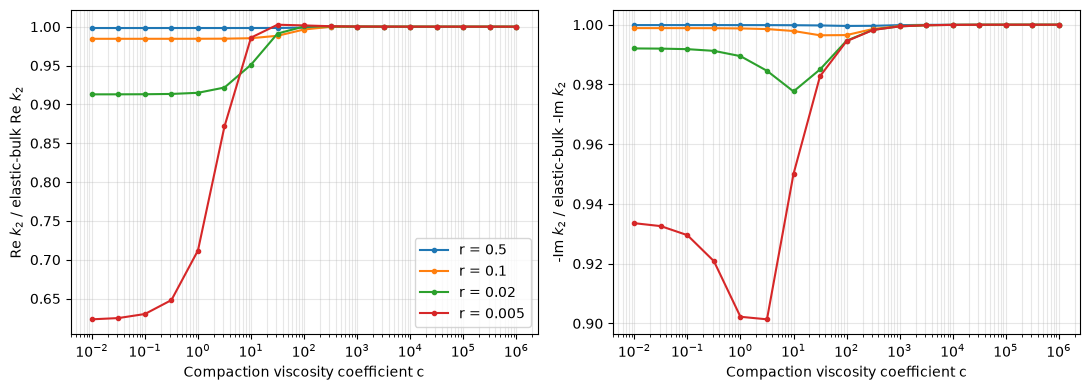

In [6]:
reference = love_k2(io_world(bulk_melt_weakening=True))
coefficients = np.logspace(-2, 6, 17)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for r in (0.5, 0.1, 0.02, 0.005):
    ratios = []
    for c in coefficients:
        world = io_world(bulk_rheology={"model": "zener", "relaxed_modulus_frac": r},
                         melt_bulk_viscosity_coefficient=c, **BULK)
        ratios.append(love_k2(world))
    ratios = np.array(ratios)
    axes[0].semilogx(coefficients, ratios.real / reference.real, "o-", ms=3, label=f"r = {r}")
    axes[1].semilogx(coefficients, ratios.imag / reference.imag, "o-", ms=3, label=f"r = {r}")
axes[0].set_ylabel("Re $k_2$ / elastic-bulk Re $k_2$")
axes[1].set_ylabel("-Im $k_2$ / elastic-bulk -Im $k_2$")
for ax in axes:
    ax.set_xlabel("Compaction viscosity coefficient c")
    ax.grid(True, which="both", alpha=0.3)
axes[0].legend()
plt.tight_layout()

- **Moderate relaxation ($r = 0.5$).** Nothing moves.
- **Strong relaxation ($r = 0.005$, a relaxed bulk modulus of about $4\times10^8$ Pa).** The layer turns compressible where the compaction relaxes within a forcing cycle, at small $c$. Re $k_2$ falls by up to about 40% and the global $-$Im $k_2$ by up to about 10%.
- **The sign of the change.** The layer does add bulk dissipation, but making it compressible also redistributes its strain, and here that costs more shear dissipation than the bulk response adds.
- **Large $c$.** The compaction viscosity is so large that the bulk response never relaxes, and every curve returns to 1.

How much bulk dissipation matters depends on the interior. Kervazo et al. (2021) found that it can rival the shear dissipation in a partially molten Io. This fitted model, with its very weak shear modulus, is close to the opposite limit.

## Density Mixing and the Structure

With `density_melt_mixing` the structure solve integrates the mixture density, so the melt changes gravity, pressure, and the mass the solve reports. The dense readout uses the same function, so `get_density` returns exactly the density the solve integrated.

mixing False: asthenosphere mass 1.2650e+22 kg, Io 8.92980e+22 kg, melt fraction 0.250
mixing True : asthenosphere mass 1.2234e+22 kg, Io 8.88722e+22 kg, melt fraction 0.250


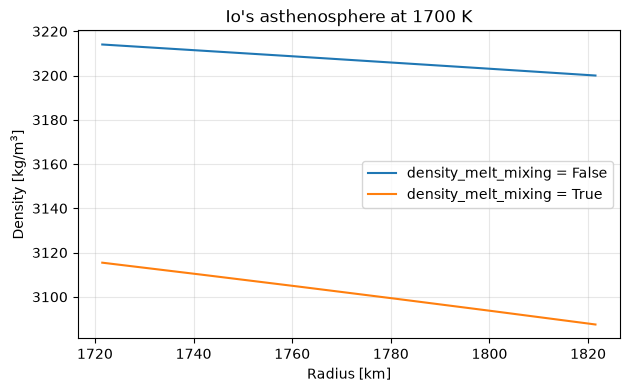

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
for mixing in (False, True):
    world = io_world(temperature=1700.0, density_melt_mixing=mixing)
    layer = world.asthenosphere
    radii = np.linspace(layer.radius_inner, layer.radius_outer, 200)
    ax.plot(radii / 1e3, [layer.get_density(r) for r in radii], label=f"density_melt_mixing = {mixing}")
    print(f"mixing {str(mixing):5s}: asthenosphere mass {layer.mass:.4e} kg, Io {world.planet_mass_eos:.5e} kg, "
          f"melt fraction {world.get_state(radii[100])['melt_fraction']:.3f}")
ax.set_xlabel("Radius [km]")
ax.set_ylabel("Density [kg/m$^3$]")
ax.set_title("Io's asthenosphere at 1700 K")
ax.grid(alpha=0.3)
ax.legend()

A world fitted to its mass without mixing holds less mass with it, so turn mixing on before fitting, not after. A layer whose melt fraction follows a solved temperature profile couples its density to its temperature, and the thermal solve then takes more passes to settle.

## Summary

| Switch | Default | What it changes | When it matters |
|---|---|---|---|
| `density_melt_mixing` | off | The structure: density, gravity, pressure, mass | Any appreciable melt; refit the mass with it on |
| `bulk_melt_weakening` | off | The unrelaxed bulk modulus | Little on its own; it sets the bulk rheology's unrelaxed modulus |
| `bulk_viscosity_melt_weakening` | off | The bulk viscosity, through the bulk rheology | Only with a non-elastic bulk rheology, and only when the relaxed bulk modulus nears the shear modulus |

Use a Zener bulk rheology, not a Maxwell one, whenever the bulk viscosity is finite: Maxwell lets the bulk modulus relax to zero, which no rock does.

**References.** McKenzie (1984), J. Petrol. 25, 713; Takei and Holtzman (2009), JGR 114, B06205; Hashin and Shtrikman (1963), J. Mech. Phys. Solids 11, 127; Kervazo et al. (2021), A&A 650, A72; Nowick and Berry (1972), Anelastic Relaxation in Crystalline Solids.